## Ensemble Learning
An ML technique that aggregates two or more learners in order to produce better predictions.

## Bagging
It uses modifies replicates of a given training data set to train multiple base learners, gen. with the same training algorithm.

## Boosting
Each models sequentially tries to correct mistakes of the previous ones.

## Out of Bag (OOB)
It's a built-in validation method in bagging that lets us estimate model performance without a separate vallidation set.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
titanic = sns.load_dataset("titanic")

features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

# handle missing data
imp_median = SimpleImputer(strategy = "median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy = "most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

# encode
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

X = titanic[features]
y = titanic["survived"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42
)

In [3]:
# Decision Tree
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Training accuracy: ", accuracy_score(y_train, y_pred_train)*100, "%")
print("Testing accuracy: ", accuracy_score(y_test, y_pred_test)*100, "%")
# over fitting

Training accuracy:  97.91332263242376 %
Testing accuracy:  76.11940298507463 %


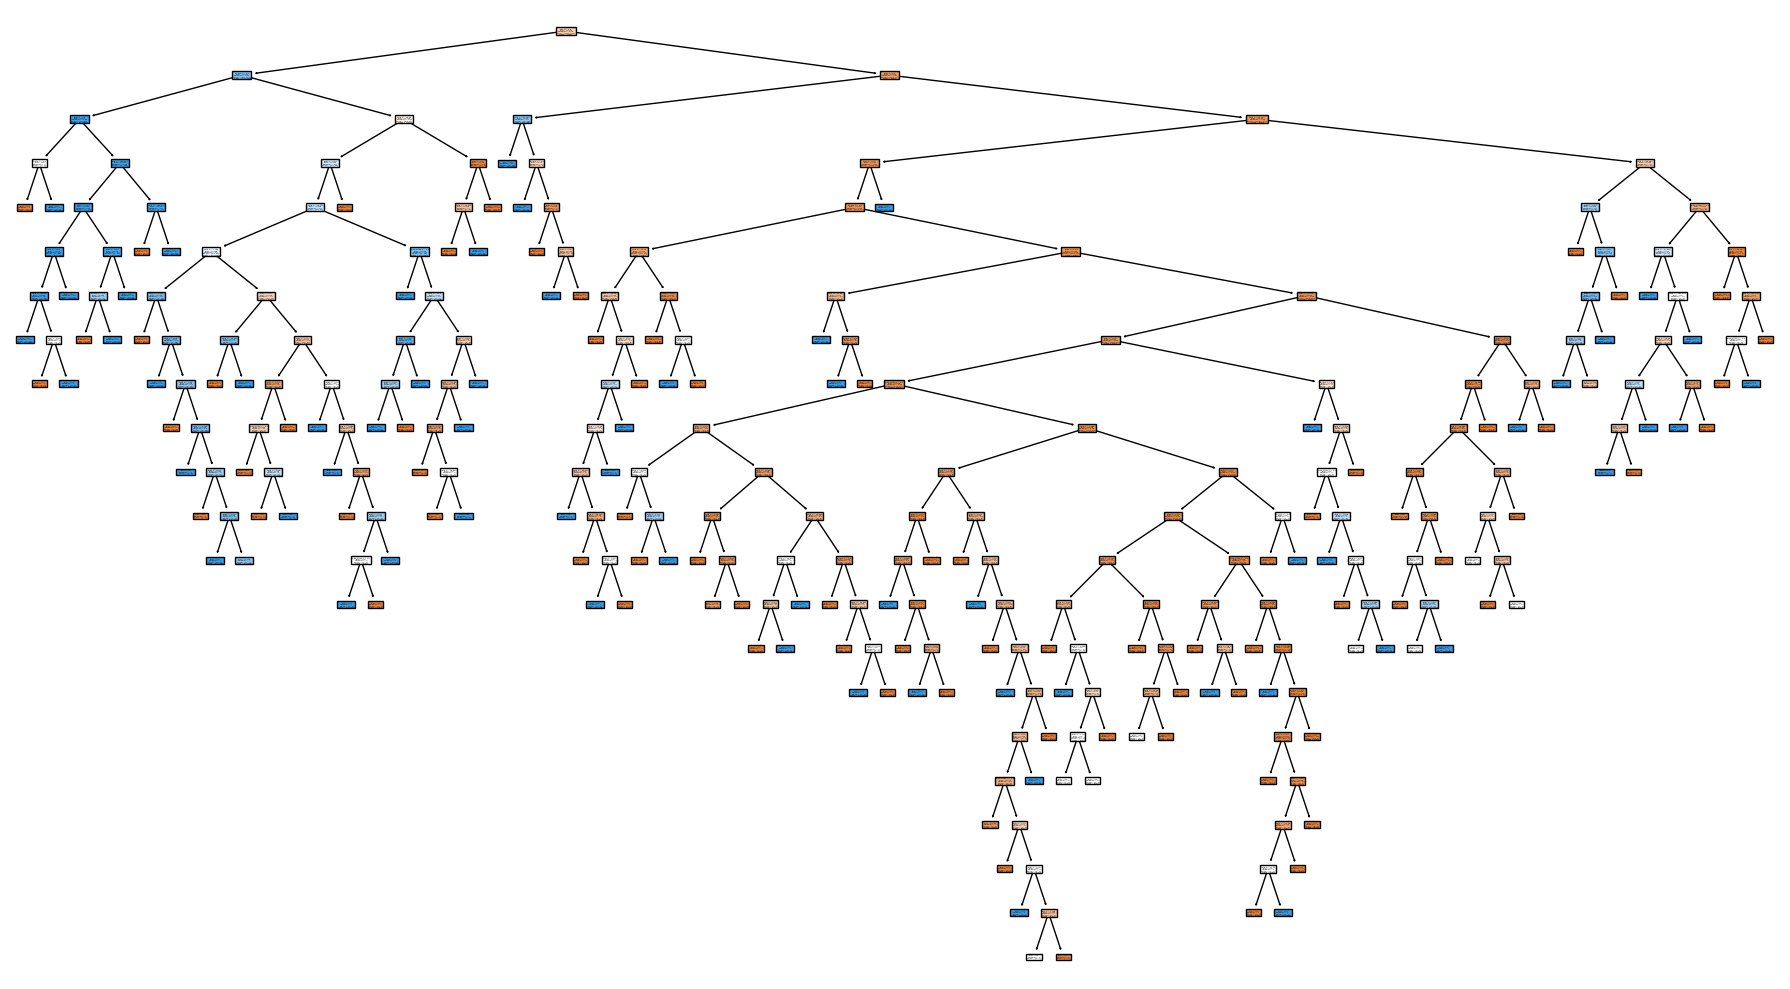

In [4]:
from sklearn.tree import plot_tree

plt.figure(figsize = (18, 10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died", "Survived"],
    filled = True
)
plt.tight_layout()

In [6]:
# random Forest Classiifier

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators = 401,
    oob_score = True
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("OOB score: ", rf.oob_score_ * 100, "%")
print("testing accuracy: ", accuracy_score(y_test, y_pred) * 100)

OOB score:  80.57784911717496 %
testing accuracy:  77.23880597014924


In [7]:
# Decision Tree - Pre Pruning
model = DecisionTreeClassifier(max_depth = 4)

model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Training accuracy: ", accuracy_score(y_train, y_pred_train)*100, "%")
print("Testing accuracy: ", accuracy_score(y_test, y_pred_test)*100, "%")

Training accuracy:  84.75120385232745 %
Testing accuracy:  82.46268656716418 %


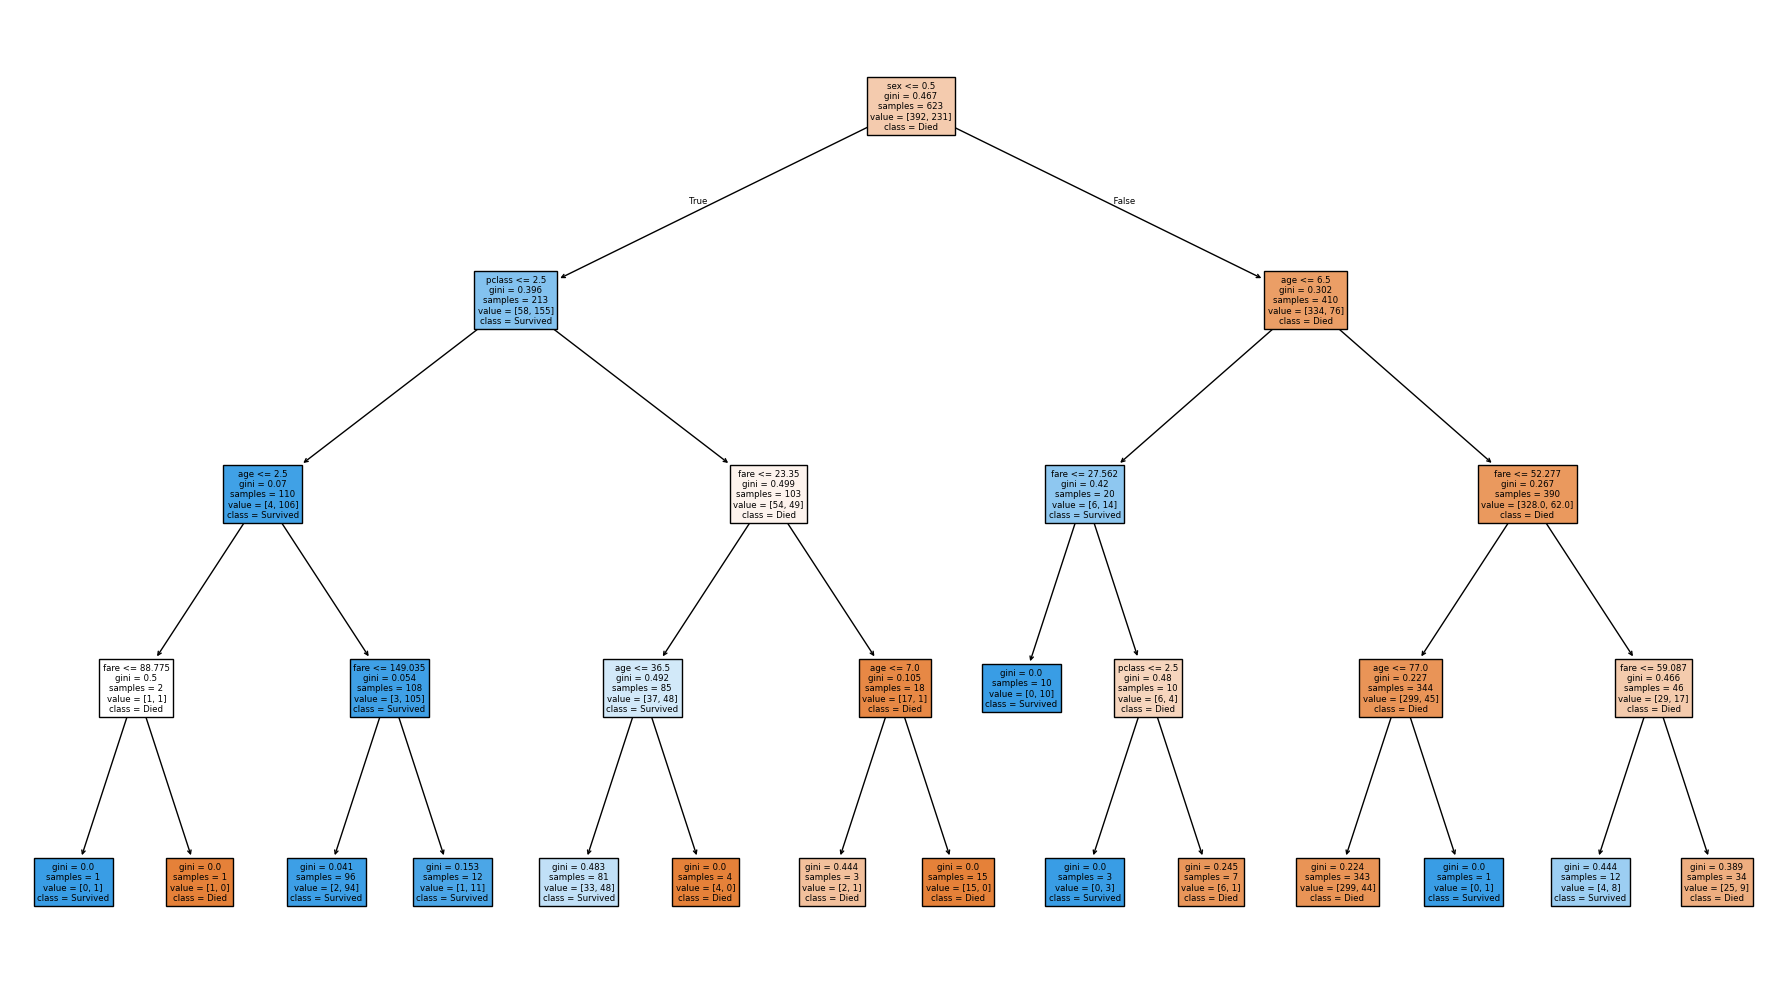

In [8]:
from sklearn.tree import plot_tree

plt.figure(figsize = (18, 10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died", "Survived"],
    filled = True
)
plt.tight_layout()

In [10]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators = 401,
    oob_score = True,
    max_depth = 4
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("OOB score: ", rf.oob_score_ * 100, "%")
print("testing accuracy: ", accuracy_score(y_test, y_pred) * 100)

OOB score:  81.38041733547352 %
testing accuracy:  81.34328358208955


In [12]:
# Bagging Classifier

from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators = 201
)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7798507462686567
